In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

print("Ready")

Ready


In [3]:
df = yf.download("SPY", start="2010-01-01",
                  end="2024-01-01", auto_adjust=True)
df.columns = df.columns.get_level_values(0)
price = df["Close"].squeeze()
log_returns = np.log(price / price.shift(1)).dropna()

print(f"Loaded {len(price)} trading days")
print(f"First date: {price.index[0].date()}")
print(f"Last date : {price.index[-1].date()}")


[*********************100%***********************]  1 of 1 completed

Loaded 3522 trading days
First date: 2010-01-04
Last date : 2023-12-29


In [4]:
# Rolling z-score
window       = 20
rolling_mean = price.rolling(window).mean()
rolling_std  = price.rolling(window).std()
zscore       = (price - rolling_mean) / rolling_std

print(f"Z-score stats:")
print(f"  Current z-score : {zscore.iloc[-1]:.2f}")
print(f"  Max z-score     : {zscore.max():.2f}")
print(f"  Min z-score     : {zscore.min():.2f}")
print(f"  Days below -2   : {(zscore < -2).sum()}")
print(f"  Days above +2   : {(zscore > 2).sum()}")

Z-score stats:
  Current z-score : 1.04
  Max z-score     : 3.09
  Min z-score     : -3.79
  Days below -2   : 163
  Days above +2   : 149


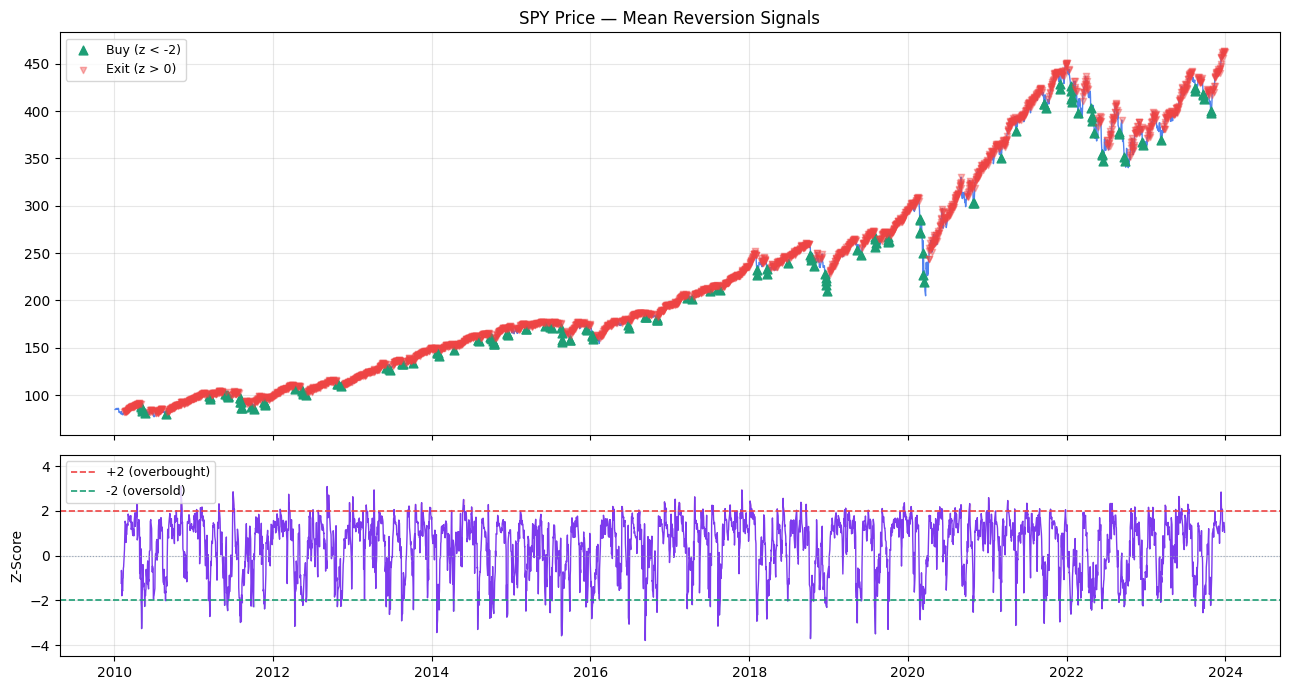

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7),
    gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

# Panel 1: Price with buy/sell markers
buy_dates  = price[zscore < -2]
exit_dates = price[zscore > 0]

ax1.plot(price, color='#2563eb', lw=1, alpha=0.8)
ax1.scatter(buy_dates.index, buy_dates,
            color='#1D9E75', marker='^', s=40,
            zorder=5, label='Buy (z < -2)')
ax1.scatter(exit_dates.index, exit_dates,
            color='#ef4444', marker='v', s=20,
            alpha=0.4, zorder=5, label='Exit (z > 0)')
ax1.set_title('SPY Price — Mean Reversion Signals')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel 2: Z-score
ax2.plot(zscore, color='#7c3aed', lw=1)
ax2.axhline( 2, color='#ef4444', lw=1.2,
             linestyle='--', label='+2 (overbought)')
ax2.axhline(-2, color='#1D9E75', lw=1.2,
             linestyle='--', label='-2 (oversold)')
ax2.axhline( 0, color='#94a3b8', lw=0.8, linestyle=':')
ax2.fill_between(zscore.index, zscore, -2,
                 where=(zscore < -2),
                 alpha=0.3, color='#1D9E75')
ax2.fill_between(zscore.index, zscore, 2,
                 where=(zscore > 2),
                 alpha=0.3, color='#ef4444')
ax2.set_ylabel('Z-Score')
ax2.set_ylim(-4.5, 4.5)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# State machine backtest
position_list = []
current_pos   = 0

for i in range(len(zscore)):
    # Entry: buy when z-score drops below -2
    if current_pos == 0 and zscore.iloc[i] < -2:
        current_pos = 1
    # Exit: sell when z-score crosses back above 0
    elif current_pos == 1 and zscore.iloc[i] > 0:
        current_pos = 0
    position_list.append(current_pos)

position = pd.Series(position_list,
                     index=zscore.index)

# Shift by 1 — no lookahead bias
position = position.shift(1).fillna(0)

# Count trades
trades   = position.diff().abs().fillna(0)
n_trades = int(trades.sum())

print(f"Total trades       : {n_trades}")
print(f"Avg trades per year: {n_trades/14:.1f}")
print(f"Time in market     : {position.mean():.1%}")

Total trades       : 122
Avg trades per year: 8.7
Time in market     : 17.8%



  Strategy              Ann Ret  Ann Vol  Sharpe    Max DD
  Mean Reversion          4.39%   12.09%    0.20   -31.83%
  Buy & Hold             12.14%   17.38%    0.58   -35.75%


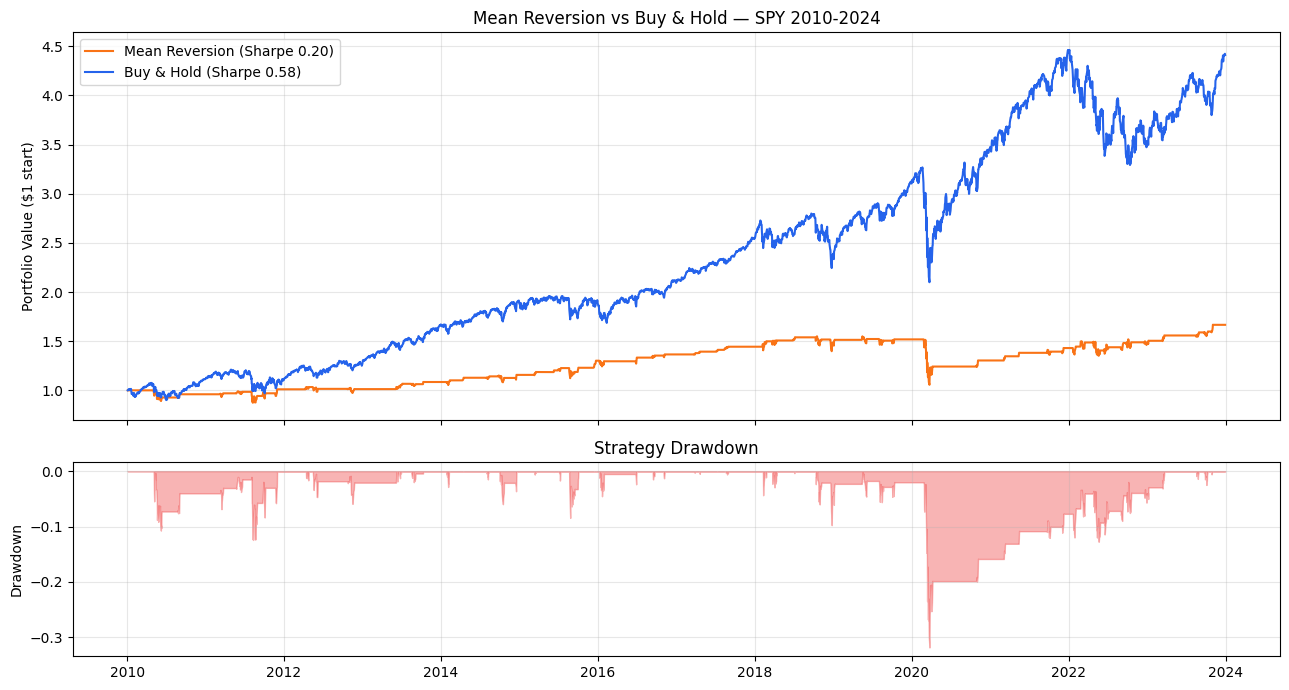

In [7]:
# Strategy returns
log_ret_aligned  = log_returns.reindex(position.index).fillna(0)
strategy_returns = position * log_ret_aligned

# Transaction costs
cost_per_trade = 0.0006
costs          = trades * cost_per_trade
net_returns    = strategy_returns - costs

# Equity curves
strategy_equity = (1 + net_returns).cumprod()
bh_equity       = (1 + log_ret_aligned).cumprod()

# Performance metrics
def metrics(r, name):
    ar = r.mean() * 252
    av = r.std()  * np.sqrt(252)
    sh = (ar - 0.02) / av
    w  = (1 + r).cumprod()
    dd = (w - w.cummax()) / w.cummax()
    return {"name": name, "ann_ret": ar,
            "ann_vol": av, "sharpe": sh,
            "max_dd": dd.min()}

strat = metrics(net_returns,     "Mean Reversion")
bh    = metrics(log_ret_aligned, "Buy & Hold")

print(f"\n{'='*58}")
print(f"  {'Strategy':<20} {'Ann Ret':>8} {'Ann Vol':>8} {'Sharpe':>7} {'Max DD':>9}")
print(f"{'='*58}")
for r in [strat, bh]:
    print(f"  {r['name']:<20} {r['ann_ret']:>8.2%} {r['ann_vol']:>8.2%} {r['sharpe']:>7.2f} {r['max_dd']:>9.2%}")
print(f"{'='*58}")

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7),
    gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

ax1.plot(strategy_equity, color='#f97316', lw=1.5,
         label=f"Mean Reversion (Sharpe {strat['sharpe']:.2f})")
ax1.plot(bh_equity,       color='#2563eb', lw=1.5,
         label=f"Buy & Hold (Sharpe {bh['sharpe']:.2f})")
ax1.set_title('Mean Reversion vs Buy & Hold — SPY 2010-2024')
ax1.set_ylabel('Portfolio Value ($1 start)')
ax1.legend()
ax1.grid(True, alpha=0.3)

dd_s = (strategy_equity - strategy_equity.cummax()) / strategy_equity.cummax()
ax2.fill_between(dd_s.index, dd_s, 0,
                 color='#ef4444', alpha=0.4)
ax2.set_title('Strategy Drawdown')
ax2.set_ylabel('Drawdown')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# Test on GLD — gold is more range-bound than SPY
df_gld = yf.download("GLD", start="2010-01-01",
                      end="2024-01-01", auto_adjust=True)
df_gld.columns = df_gld.columns.get_level_values(0)
price_gld = df_gld["Close"].squeeze()
log_ret_gld = np.log(price_gld / price_gld.shift(1)).dropna()

# Z-score
rm  = price_gld.rolling(20).mean()
rs  = price_gld.rolling(20).std()
z   = (price_gld - rm) / rs

# State machine
pos_list = []
cp = 0
for i in range(len(z)):
    if cp == 0 and z.iloc[i] < -2:
        cp = 1
    elif cp == 1 and z.iloc[i] > 0:
        cp = 0
    pos_list.append(cp)

pos_gld = pd.Series(pos_list, index=z.index).shift(1).fillna(0)
trades_gld = pos_gld.diff().abs().fillna(0)

# Returns
lr_gld  = log_ret_gld.reindex(pos_gld.index).fillna(0)
net_gld = pos_gld * lr_gld - trades_gld * 0.0006
bh_gld  = lr_gld

strat_gld = metrics(net_gld, "GLD Mean Rev")
bh_gld_m  = metrics(bh_gld,  "GLD Buy&Hold")

print(f"\n{'='*58}")
print(f"  {'Strategy':<20} {'Ann Ret':>8} {'Ann Vol':>8} {'Sharpe':>7} {'Max DD':>9}")
print(f"{'='*58}")
for r in [strat_gld, bh_gld_m]:
    print(f"  {r['name']:<20} {r['ann_ret']:>8.2%} {r['ann_vol']:>8.2%} {r['sharpe']:>7.2f} {r['max_dd']:>9.2%}")
print(f"{'='*58}")

[*********************100%***********************]  1 of 1 completed


  Strategy              Ann Ret  Ann Vol  Sharpe    Max DD
  GLD Mean Rev            0.99%    8.28%   -0.12   -22.89%
  GLD Buy&Hold            3.97%   15.56%    0.13   -49.22%


In [9]:
def mean_reversion_backtest(ticker, window=20,
                             entry_z=-2, exit_z=0,
                             start="2010-01-01",
                             end="2024-01-01",
                             cost_pct=0.0006):
    """
    Z-score mean reversion backtest.
    Buy when z < entry_z, exit when z > exit_z.
    """
    # Data
    df = yf.download(ticker, start=start,
                     end=end, auto_adjust=True)
    df.columns = df.columns.get_level_values(0)
    price   = df["Close"].squeeze()
    log_ret = np.log(price / price.shift(1)).dropna()

    # Z-score
    rm     = price.rolling(window).mean()
    rs     = price.rolling(window).std()
    zscore = (price - rm) / rs

    # State machine
    pos_list, cp = [], 0
    for i in range(len(zscore)):
        if cp == 0 and zscore.iloc[i] < entry_z:
            cp = 1
        elif cp == 1 and zscore.iloc[i] > exit_z:
            cp = 0
        pos_list.append(cp)

    position = pd.Series(pos_list,
                         index=zscore.index).shift(1).fillna(0)
    trades   = position.diff().abs().fillna(0)

    # Returns
    lr      = log_ret.reindex(position.index).fillna(0)
    net_ret = position * lr - trades * cost_pct

    # Metrics
    ar = net_ret.mean() * 252
    av = net_ret.std()  * np.sqrt(252)
    sh = (ar - 0.02) / av
    w  = (1 + net_ret).cumprod()
    dd = (w - w.cummax()) / w.cummax()

    print(f"\n{'='*50}")
    print(f"  {ticker} MEAN REVERSION BACKTEST")
    print(f"{'='*50}")
    print(f"  Window     : {window} days")
    print(f"  Entry z    : {entry_z}")
    print(f"  Exit z     : {exit_z}")
    print(f"  Ann Return : {ar:.2%}")
    print(f"  Ann Vol    : {av:.2%}")
    print(f"  Sharpe     : {sh:.2f}")
    print(f"  Max DD     : {dd.min():.2%}")
    print(f"  N Trades   : {int(trades.sum())}")
    print(f"  Time in mkt: {position.mean():.1%}")
    print(f"{'='*50}")

    return {"sharpe": sh, "ann_ret": ar,
            "max_dd": dd.min(),
            "n_trades": int(trades.sum())}

# Test on multiple assets
for ticker in ["SPY", "GLD", "TLT"]:
    mean_reversion_backtest(ticker)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


  SPY MEAN REVERSION BACKTEST
  Window     : 20 days
  Entry z    : -2
  Exit z     : 0
  Ann Return : 4.39%
  Ann Vol    : 12.09%
  Sharpe     : 0.20
  Max DD     : -31.83%
  N Trades   : 122
  Time in mkt: 17.8%



  GLD MEAN REVERSION BACKTEST
  Window     : 20 days
  Entry z    : -2
  Exit z     : 0
  Ann Return : 0.99%
  Ann Vol    : 8.28%
  Sharpe     : -0.12
  Max DD     : -22.89%
  N Trades   : 116
  Time in mkt: 22.9%


[*********************100%***********************]  1 of 1 completed


  TLT MEAN REVERSION BACKTEST
  Window     : 20 days
  Entry z    : -2
  Exit z     : 0
  Ann Return : 0.16%
  Ann Vol    : 7.52%
  Sharpe     : -0.24
  Max DD     : -26.15%
  N Trades   : 118
  Time in mkt: 24.3%
